# Cyclistic Case Study – Analyze

This notebook explores differences in **bike usage patterns between annual members and casual riders** using the cleaned dataset.

## Analysis Objective

The objective of this analysis is to identify behavioral differences between annual members and casual riders.  
These insights will help Cyclistic design targeted marketing strategies aimed at converting casual riders into annual members.

## Scope of Analysis

The analysis focuses on:
- Trip duration
- Ride frequency
- Time of day usage
- Weekday vs weekend behavior
- Seasonal patterns

All analysis is performed using SQL queries on the processed dataset.


## DataBase connection


In [2]:
from sqlalchemy import create_engine
import pandas as pd

server = "Knok\\SQLEXPRESS"
database = "Analysis"

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}"
    "?driver=ODBC+Driver+17+for+SQL+Server"
    "&trusted_connection=yes"
)

## Analysis 01: Weekday vs Weekend Usage by Rider Type

How does ride frequency differ between annual members and casual riders during weekdays and weekends?

In [3]:
import pandas as pd

query_weekend = """
SELECT
    member_casual,
    is_weekend,
    COUNT(*) AS total_rides
FROM dbo.cyclistic
GROUP BY
    member_casual,
    is_weekend
ORDER BY
    member_casual,
    is_weekend;
"""

df_weekend = pd.read_sql(query_weekend, con=engine)
df_weekend

,member_casual,is_weekend,total_rides
0,casual,False,7723328
1,casual,True,4809341
2,member,False,14759201
3,member,True,4873793


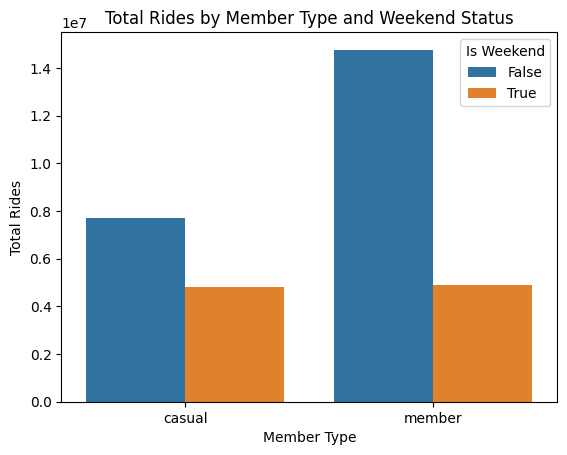

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(data=df_weekend, x="member_casual", y="total_rides", hue="is_weekend")
plt.title("Total Rides by Member Type and Weekend Status")
plt.xlabel("Member Type")
plt.ylabel("Total Rides")
plt.legend(title="Is Weekend")
